In [36]:
import pandas as pd

In [37]:
df = pd.read_csv("predict+students+dropout+and+academic+success/data.csv",sep=";")


# EDA

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [39]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [40]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [41]:
df.nunique()

Marital status                                      6
Application mode                                   18
Application order                                   8
Course                                             17
Daytime/evening attendance\t                        2
Previous qualification                             17
Previous qualification (grade)                    101
Nacionality                                        21
Mother's qualification                             29
Father's qualification                             34
Mother's occupation                                32
Father's occupation                                46
Admission grade                                   620
Displaced                                           2
Educational special needs                           2
Debtor                                              2
Tuition fees up to date                             2
Gender                                              2
Scholarship holder          

In [42]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df["Admission grade"].describe()

count    4424.000000
mean      126.978119
std        14.482001
min        95.000000
25%       117.900000
50%       126.100000
75%       134.800000
max       190.000000
Name: Admission grade, dtype: float64

In [45]:
df.groupby("Target")["Curricular units 1st sem (grade)"].mean()

Target
Dropout      7.256656
Enrolled    11.125257
Graduate    12.643655
Name: Curricular units 1st sem (grade), dtype: float64

In [46]:
df["Daytime/evening attendance\t"].value_counts()#just gives timmings 

Daytime/evening attendance\t
1    3941
0     483
Name: count, dtype: int64

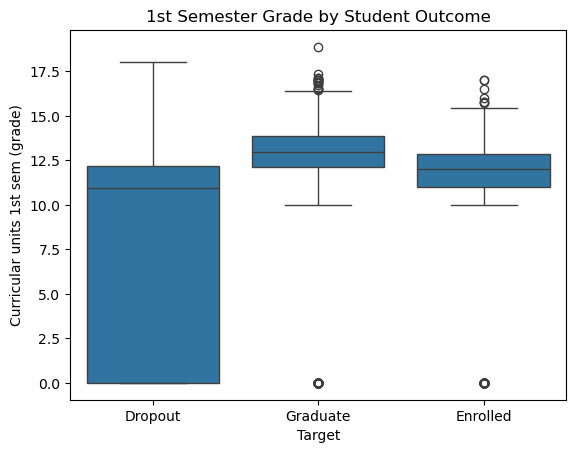

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="Target",
    y="Curricular units 1st sem (grade)",
    data=df
)

plt.title("1st Semester Grade by Student Outcome")
plt.show()

DROPOUT: median 11 menas 50% stuentshave grade below 11 and rest 50 above 11

In [48]:
df.groupby("Target")["Curricular units 1st sem (approved)"].mean()

Target
Dropout     2.551724
Enrolled    4.318640
Graduate    6.232232
Name: Curricular units 1st sem (approved), dtype: float64

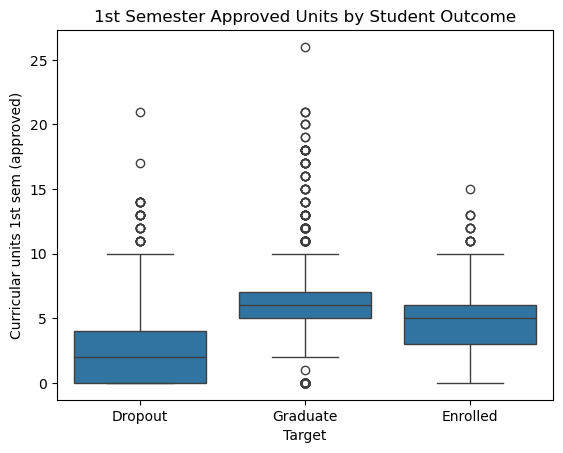

In [49]:
sns.boxplot(
    x="Target",
    y="Curricular units 1st sem (approved)",
    data=df
)

plt.title("1st Semester Approved Units by Student Outcome")
plt.show()

In [50]:
df[[
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (approved)"
]].corr()

,Curricular units 1st sem (grade),Curricular units 1st sem (approved)
Curricular units 1st sem (grade),1.000000,0.696113
Curricular units 1st sem (approved),0.696113,1.000000


In [53]:
pd.crosstab(df["Tuition fees up to date"], df["Target"],normalize="index")#showscategory wise how many paid fessand not
# we need to see in percefntageas categoriescand beimblance sonumbers is not ww have tolokfor

Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,0.865530,0.079545,0.054924
1,0.247433,0.193018,0.559548


In [54]:
df["Course"].value_counts()

Course
9500    766
9147    380
9238    355
9085    337
9773    331
9670    268
9991    268
9254    252
9070    226
171     215
8014    215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
Name: count, dtype: int64

In [55]:
pd.crosstab(
    df["Course"],
    df["Target"],
    normalize="index"
)

Target,Dropout,Enrolled,Graduate
Course,,,
33,0.666667,0.250000,0.083333
171,0.381395,0.172093,0.446512
8014,0.330233,0.097674,0.572093
9003,0.409524,0.176190,0.414286
9070,0.225664,0.185841,0.588496
9085,0.267062,0.222552,0.510386
9119,0.541176,0.376471,0.082353
9130,0.553191,0.148936,0.297872
9147,0.352632,0.284211,0.363158


In [56]:
df.groupby("Target")["Age at enrollment"].mean()

Target
Dropout     26.068966
Enrolled    22.369018
Graduate    21.783612
Name: Age at enrollment, dtype: float64

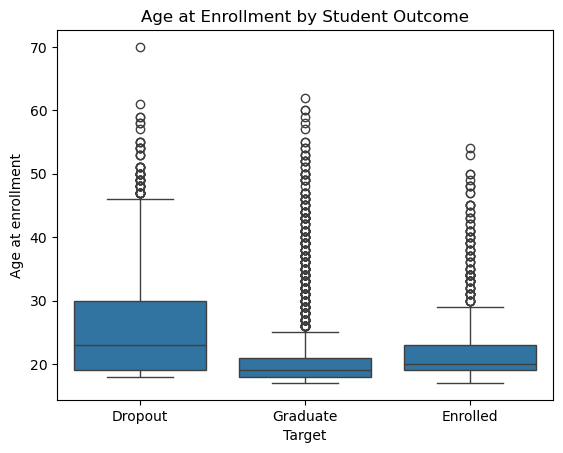

In [57]:
sns.boxplot(
    x="Target",
    y="Age at enrollment",
    data=df
)

plt.title("Age at Enrollment by Student Outcome")
plt.show()

we will evaluate after 1st sem whether student will remain or dropout so remove the columns of2nd sem

In [61]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [ ]:
cols= ["Curricular units 2nd sem (credited)","Curricular units 2nd sem (enrolled)","Curricular units 2nd sem (evaluations)","Curricular units 2nd sem (approved)","Curricular units 2nd sem (grade)","Curricular units 2nd sem (without evaluations)"]
new_df = df.drop(columns = cols)


X = new_df.drop("Target",axis = 1)
Y = new_df["Target"]

Y

before training model we must know which features are numeric,categorical,

In [70]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 30 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

we treat cateforesand numerical diffently as numbersmaining changes

In [71]:
numeric_cols = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]
categorical_cols = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance\t",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

# PREPROCESSING

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [74]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(3539, 30)
(885, 30)
Target
Graduate    0.499294
Dropout     0.321277
Enrolled    0.179429
Name: proportion, dtype: float64
Target
Graduate    0.499435
Dropout     0.320904
Enrolled    0.179661
Name: proportion, dtype: float64


In [75]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [83]:
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown ="ignore")#"I didn't see this category during training, so I'll encode it as all zeros for this feature."
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_numeric = scaler.transform(X_test[numeric_cols])
X_test_categorical = encoder.transform(X_test[categorical_cols])

In [84]:
#since we have 2 seperateecolumns of test and train weneed to combine them
from scipy.sparse import hstack

X_train_processed = hstack([X_train_num, X_train_cat])
X_test_processed = hstack([X_test_numeric, X_test_categorical])
#hstack() = join our processed numerical + categorical features side-by-side.

In [85]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(3539, 245)
(885, 245)


🧠 What we've done

1. Loaded and understood the dataset

4,424 students
36 input features + Target
Target = Dropout, Enrolled, Graduate

2. Did EDA
We asked questions like:

Are there missing values? → No
Are there duplicates? → No
Which features relate to the outcome?
How do grades, approved units, age, tuition status, course, etc. differ between groups?

This helped us understand the data before modeling.

3. Decided our prediction point
We decided:

🔮 Predict the student's outcome after 1st semester.

Therefore, we removed all 2nd-semester features because they wouldn't be available at prediction time.

That's how we avoided data leakage.

4. Separated input and target

X = features
Y = Target

So:

X → information about student
Y → Dropout / Enrolled / Graduate

5. Identified feature types

We separated:

Numerical → grades, age, units, economic indicators...
Categorical → course, qualification, gender, tuition status...

Because they need different preprocessing.

6. Split the data

80% → Training → 3539 students
20% → Testing  → 885 students

Training = model learns from it.

Testing = later we check whether the model works on unseen students.

7. Preprocessed the data

Numerical:

StandardScaler

Categorical:

OneHotEncoder

Then we combined them using:

hstack()

Result:

3539 × 245 → training data
885 × 245  → testing data

The 30-ish original columns became 245 features because categorical columns were expanded through one-hot encoding.

🚀 What we do now

Now the data is ready.

The next phase is:

Preprocessing ✅
       ↓
Train model ← WE ARE HERE
       ↓
Make predictions
       ↓
Evaluate model
       ↓
Improve model
       ↓
Build final project

So our very next step is simply:

Train our first baseline classification model.

In [87]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [90]:
y_pred = model.predict(X_test_processed)
print(y_pred[:10])

['Graduate' 'Graduate' 'Graduate' 'Graduate' 'Graduate' 'Graduate'
 'Graduate' 'Graduate' 'Graduate' 'Graduate']


In [91]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.45      0.30      0.36       159
    Graduate       0.77      0.90      0.83       442

    accuracy                           0.74       885
   macro avg       0.67      0.65      0.65       885
weighted avg       0.72      0.74      0.72       885



In [92]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[212  31  41]
 [ 38  47  74]
 [ 20  26 396]]


In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)
rf_pred = rf_model.predict(X_test_processed)
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

     Dropout       0.73      0.72      0.73       284
    Enrolled       0.42      0.17      0.24       159
    Graduate       0.75      0.92      0.83       442

    accuracy                           0.72       885
   macro avg       0.64      0.60      0.60       885
weighted avg       0.69      0.72      0.69       885



In [94]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf")

svm_model.fit(X_train_processed, y_train)
svm_pred = svm_model.predict(X_test_processed)
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

     Dropout       0.80      0.68      0.73       284
    Enrolled       0.45      0.28      0.35       159
    Graduate       0.75      0.93      0.83       442

    accuracy                           0.73       885
   macro avg       0.67      0.63      0.64       885
weighted avg       0.71      0.73      0.71       885



In [95]:
class_weight="balanced"

In [96]:
weighted_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"#Don't treat every class equally according to its frequency. Give more importance to the underrepresented classes.
)

weighted_model.fit(X_train_processed, y_train)
weighted_pred = weighted_model.predict(X_test_processed)
print(classification_report(y_test, weighted_pred))

              precision    recall  f1-score   support

     Dropout       0.78      0.68      0.73       284
    Enrolled       0.38      0.56      0.46       159
    Graduate       0.83      0.76      0.79       442

    accuracy                           0.70       885
   macro avg       0.67      0.67      0.66       885
weighted avg       0.73      0.70      0.71       885



Try Logistic Regression
        ↓
Enrolled performance is poor
        ↓
Try Random Forest + SVM
        ↓
Enrolled still poor
        ↓
Check class distribution
        ↓
Enrolled is the smallest class
        ↓
Hypothesis: class imbalance may contribute
        ↓
Try class_weight="balanced"
        ↓
Enrolled recall improves 30% → 56%
        ↓
But other performance decreases

In [97]:
results = {
    "Logistic Regression": [0.74, 0.77, 0.36, 0.83],
    "Random Forest": [0.72, 0.73, 0.24, 0.83],
    "SVM": [0.73, 0.73, 0.35, 0.83],
    "Balanced Logistic": [0.70, 0.73, 0.46, 0.79]
}

comparison = pd.DataFrame(
    results,
    index=["Accuracy", "Dropout F1", "Enrolled F1", "Graduate F1"]
).T

print(comparison)

                     Accuracy  Dropout F1  Enrolled F1  Graduate F1
Logistic Regression      0.74        0.77         0.36         0.83
Random Forest            0.72        0.73         0.24         0.83
SVM                      0.73        0.73         0.35         0.83
Balanced Logistic        0.70        0.73         0.46         0.79


In [98]:
feature_names = (
    numeric_cols +
    list(encoder.get_feature_names_out(categorical_cols))
)

print(len(feature_names))
print(feature_names[:20])

245
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Marital status_1', 'Marital status_2', 'Marital status_3', 'Marital status_4', 'Marital status_5', 'Marital status_6', 'Application mode_1', 'Application mode_2']


In [99]:
coefficients = pd.DataFrame(
    model.coef_,
    columns=feature_names,
    index=model.classes_
)

print(coefficients)

          Previous qualification (grade)  Admission grade  Age at enrollment  \
Dropout                         0.034139        -0.018373           0.134337   
Enrolled                       -0.044113        -0.042474          -0.046896   
Graduate                        0.009974         0.060847          -0.087441   

          Curricular units 1st sem (credited)  \
Dropout                              0.442787   
Enrolled                            -0.239778   
Graduate                            -0.203009   

          Curricular units 1st sem (enrolled)  \
Dropout                               0.80146   
Enrolled                              0.15641   
Graduate                             -0.95787   

          Curricular units 1st sem (evaluations)  \
Dropout                                -0.095616   
Enrolled                                0.386267   
Graduate                               -0.290651   

          Curricular units 1st sem (approved)  \
Dropout                    

In [100]:
for class_name in coefficients.index:
    print(f"\n{class_name}")
    print(coefficients.loc[class_name].abs().sort_values(ascending=False).head(10))


Dropout
Curricular units 1st sem (approved)    1.739499
Mother's occupation_0                  1.248471
Course_171                             1.197320
Mother's occupation_191                1.132283
Application mode_15                    1.097083
Father's occupation_90                 1.087449
Tuition fees up to date_0              0.946087
Previous qualification_2               0.910257
Course_9853                            0.886714
Tuition fees up to date_1              0.874864
Name: Dropout, dtype: float64

Enrolled
Mother's occupation_0        1.472061
Mother's occupation_90       1.212475
Father's qualification_39    1.171379
Father's occupation_90       1.026493
Course_9119                  0.991341
Father's occupation_0        0.781979
Application mode_5           0.740037
Mother's qualification_9     0.736665
Application mode_10          0.719544
Mother's occupation_192      0.686823
Name: Enrolled, dtype: float64

Graduate
Curricular units 1st sem (approved)    2.094907
Co

In [101]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train_processed, y_train)

dummy_pred = dummy.predict(X_test_processed)

print(classification_report(y_test, dummy_pred))

              precision    recall  f1-score   support

     Dropout       0.00      0.00      0.00       284
    Enrolled       0.00      0.00      0.00       159
    Graduate       0.50      1.00      0.67       442

    accuracy                           0.50       885
   macro avg       0.17      0.33      0.22       885
weighted avg       0.25      0.50      0.33       885



C:\Users\ARYAN DIXIT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ARYAN DIXIT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ARYAN DIXIT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
